# Bài tập thực hành Buổi 3
## Luật Hebb – Hopfield khử nhiễu ký hiệu giao thông

**Bối cảnh:** Một camera giao thông chụp lại ký hiệu trên bảng báo nhưng ảnh bị nhiễu vài điểm ảnh (bụi, mưa, ánh sáng). Ta dùng mạng Hopfield để phục hồi đúng ký hiệu đã lưu, tương tự cách buổi học phục hồi chữ C/I/T — nhưng lần này là ba ký hiệu giao thông trên lưới 4×4:

- **↑ Đi thẳng**
- **← Rẽ trái**
- **✕ Cấm / Dừng**

**Hướng dẫn:**
- Làm phép tính tay trước (viết trên giấy hoặc comment).
- Điền code vào các ô `# TODO` để kiểm tra kết quả.
- Mỗi bài có ô đáp án ẩn — chỉ mở sau khi tự làm xong.

**Thang điểm:** A (2đ) + B (3đ) + C (3đ) + D (2đ) = 10 điểm

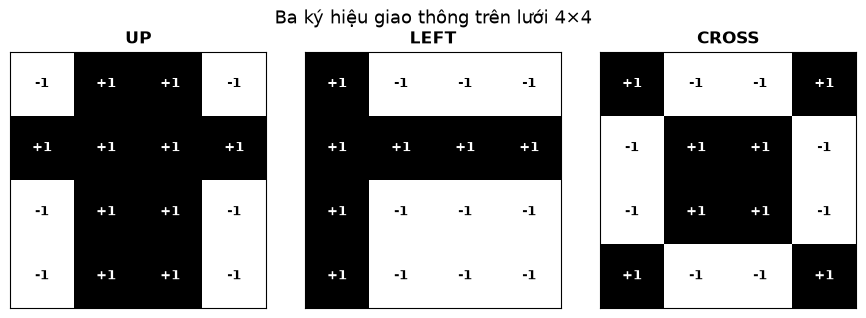

Quy ước đánh số 16 ô (trái→phải, trên→dưới):
1  2  3  4
5  6  7  8
9  10 11 12
13 14 15 16


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Ba ký hiệu chuẩn trên lưới 4x4 (đã cho sẵn, không cần sửa)
# Quy ước: 1 = điểm sáng (bật), -1 = điểm tối (tắt)
patterns = {
    'UP': np.array([-1, 1, 1,-1,
                     1, 1, 1, 1,
                    -1, 1, 1,-1,
                    -1, 1, 1,-1], dtype=float),
    'LEFT': np.array([1,-1,-1,-1,
                       1, 1, 1, 1,
                       1,-1,-1,-1,
                       1,-1,-1,-1], dtype=float),
    'CROSS': np.array([1,-1,-1, 1,
                       -1, 1, 1,-1,
                       -1, 1, 1,-1,
                        1,-1,-1, 1], dtype=float),
}

def show_grid(ax, vec, title):
    grid = vec.reshape(4, 4)
    ax.imshow(grid, cmap='gray_r', vmin=-1, vmax=1)
    for i in range(4):
        for j in range(4):
            val = grid[i, j]
            color = 'white' if val == 1 else 'black'
            ax.text(j, i, f'{int(val):+d}', ha='center', va='center',
                    fontsize=9, color=color, fontweight='bold')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])

fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))
for ax, (name, p) in zip(axes, patterns.items()):
    show_grid(ax, p, name)
plt.suptitle('Ba ký hiệu giao thông trên lưới 4×4', fontsize=13)
plt.tight_layout()
plt.show()

print("Quy ước đánh số 16 ô (trái→phải, trên→dưới):")
print("1  2  3  4")
print("5  6  7  8")
print("9  10 11 12")
print("13 14 15 16")

---
## Bài A — Luật Hebb: tính tay bốn trọng số (2 điểm)

**Yêu cầu:** Tính `w₁,₁₃`, `w₁,₄`, `w₁,₅`, `w₁,₂` bằng luật Hebb:
```
wᵢⱼ = ξᵢ^UP·ξⱼ^UP + ξᵢ^LEFT·ξⱼ^LEFT + ξᵢ^CROSS·ξⱼ^CROSS
```
Với mỗi cặp, viết ra 3 tích (một cho mỗi ký hiệu UP, LEFT, CROSS) rồi cộng lại, sau đó kiểm tra bằng code.

In [2]:
# Bài A.1: Dựng ma trận W đầy đủ từ ba ký hiệu (đã cho sẵn công thức)
xiUP, xiLEFT, xiCROSS = patterns['UP'], patterns['LEFT'], patterns['CROSS']

W = np.outer(xiUP, xiUP) + np.outer(xiLEFT, xiLEFT) + np.outer(xiCROSS, xiCROSS)
np.fill_diagonal(W, 0)

print("Ma trận W đã dựng xong, kích thước:", W.shape)

Ma trận W đã dựng xong, kích thước: (16, 16)


In [3]:
# Bài A.2: Tính tay rồi điền kết quả để đối chiếu
# Gợi ý: xem giá trị ξ_i, ξ_j trên từng ký hiệu (UP, LEFT, CROSS) tại vị trí cần tính

def get_value(name, index_1based):
    """Lấy giá trị (+1/-1) của một ô trên một ký hiệu, index tính từ 1."""
    return patterns[name][index_1based - 1]

pairs = [(1, 13), (1, 4), (1, 5), (1, 2)]

for i, j in pairs:
    # TODO: tính tích ξ_i * ξ_j trên từng ký hiệu rồi cộng lại
    tich_UP = get_value("UP", i) * get_value("UP", j);    # TODO: get_value('UP', i) * get_value('UP', j)
    tich_LEFT = get_value("LEFT", i) * get_value("LEFT", j);  # TODO
    tich_CROSS = get_value("CROSS", i) * get_value("CROSS", j); # TODO
    w_tay = tich_UP + tich_LEFT + tich_CROSS;      # TODO: tổng ba tích

    w_thuc = W[i - 1, j - 1]
    status = "OK" if w_tay == w_thuc else "SAI"
    print(f"w_{i},{j}: tính tay = {w_tay} | W thực = {int(w_thuc)} -> {status}")

w_1,13: tính tay = 3.0 | W thực = 3 -> OK
w_1,4: tính tay = 1.0 | W thực = 1 -> OK
w_1,5: tính tay = -1.0 | W thực = -1 -> OK
w_1,2: tính tay = -3.0 | W thực = -3 -> OK


<details>
<summary><b>👉 Xem đáp án Bài A</b></summary>

```python
tich_UP = get_value('UP', i) * get_value('UP', j)
tich_LEFT = get_value('LEFT', i) * get_value('LEFT', j)
tich_CROSS = get_value('CROSS', i) * get_value('CROSS', j)
w_tay = tich_UP + tich_LEFT + tich_CROSS
```

Kết quả: `w₁,₁₃ = 3`, `w₁,₄ = 1`, `w₁,₅ = -1`, `w₁,₂ = -3`.

</details>

---
## Bài B — Hopfield: vá ký hiệu Rẽ trái (LEFT) bị nhiễu 2 điểm (3 điểm)

**Bối cảnh:** Camera chụp biển báo "Rẽ trái" trong lúc mưa, hai điểm ảnh bị nhiễu: ô 6 và ô 14 (đổi dấu).

### Yêu cầu:
1. Tạo input `x(0)` bằng cách lật đúng hai ô trên ký hiệu LEFT.
2. Tính `net₆` và `net₁₄` bằng tay (dùng hàng W tương ứng), so với code.
3. Áp dụng `sign(·)` cho cả hai ô và kiểm tra ảnh có trở về ký hiệu LEFT sạch không.

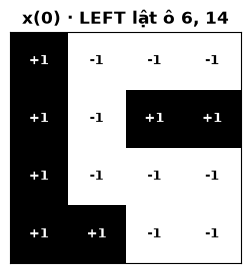

x(0) = [1, -1, -1, -1, 1, -1, 1, 1, 1, -1, -1, -1, 1, 1, -1, -1]


In [4]:
# Bài B.1: Tạo input nhiễu (LEFT lật ô 6 và ô 14)

x0 = patterns['LEFT'].copy()
# TODO: lật ô 6 (chỉ số 0-based: 5) và ô 14 (chỉ số 0-based: 13)
x0[5] *= -1  # TODO: ô 6
x0[13] *= -1  # TODO: ô 14

fig, ax = plt.subplots(1, 1, figsize=(3, 3))
show_grid(ax, x0, 'x(0) · LEFT lật ô 6, 14')
plt.show()

print(f"x(0) = {x0.astype(int).tolist()}")

In [5]:
# Bài B.2: Tính net cho ô 6 và ô 14
# net_i = W[i] @ x  (dùng chỉ số 0-based: ô 6 -> hàng 5, ô 14 -> hàng 13)

net_6 = W[5] @ x0 # TODO: W[5] @ x0
net_14 = W[13] @ x0  # TODO: W[13] @ x0

print(f"net_6  = {net_6}")
print(f"net_14 = {net_14}")

net_6  = 11.0
net_14 = -15.0


x sau khi vá = [1, -1, -1, -1, 1, 1, 1, 1, 1, -1, -1, -1, 1, -1, -1, -1]
Khớp ký hiệu LEFT sạch: True


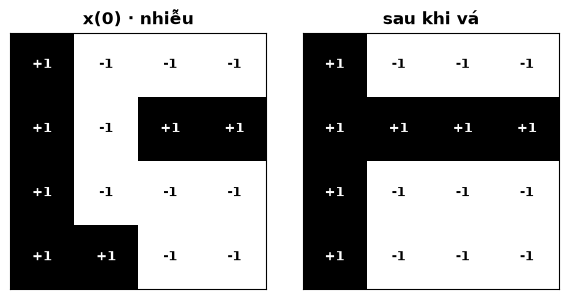

In [6]:
# Bài B.3: Áp dụng sign() cho cả hai ô, cập nhật x0 rồi kiểm tra kết quả

def sign(val, current):
    if val > 0:
        return 1.0
    elif val < 0:
        return -1.0
    else:
        return current

x_result = x0.copy()
# TODO: cập nhật ô 6 rồi ô 14 (nhớ: sau khi đổi ô 6, x_result đã thay đổi
# nên net của ô 14 phải tính lại trên x_result mới, không dùng lại net_14 ở trên)
x_result[5] = sign(W[5] @ x_result, x_result[5])   # TODO: sign(W[5] @ x_result, x_result[5])
x_result[13] = sign(W[13] @ x_result, x_result[13])  # TODO: sign(W[13] @ x_result, x_result[13])

ok = np.array_equal(x_result, patterns['LEFT'])
print(f"x sau khi vá = {x_result.astype(int).tolist()}")
print(f"Khớp ký hiệu LEFT sạch: {ok}")

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
show_grid(axes[0], x0, 'x(0) · nhiễu')
show_grid(axes[1], x_result, 'sau khi vá')
plt.tight_layout()
plt.show()

<details>
<summary><b>👉 Xem đáp án Bài B</b></summary>

```python
x0 = patterns['LEFT'].copy()
x0[5] *= -1   # ô 6
x0[13] *= -1  # ô 14

net_6 = W[5] @ x0
net_14 = W[13] @ x0

x_result = x0.copy()
x_result[5] = sign(W[5] @ x_result, x_result[5])
x_result[13] = sign(W[13] @ x_result, x_result[13])
```

Kết quả: `net_6 = 11`, `net_14 = -15` trên `x(0)` (ô 6 dương nên tô sáng, ô 14 âm nên tô tối — đúng với LEFT chuẩn).
Sau khi vá cả hai ô, `x_result` khớp đúng ký hiệu LEFT sạch → `True`.

</details>

---
## Bài C — Năng lượng: theo dõi E khi vá ký hiệu Cấm (CROSS) (3 điểm)

**Bối cảnh:** Biển báo "Cấm" (✕) bị một hạt bụi che ô 6.

### Yêu cầu:
1. Tính năng lượng `E` của trạng thái nhiễu ban đầu.
2. Vá ô 6 bằng `sign(net₆)`.
3. Tính lại `E` sau khi vá và so sánh — `E` phải giảm hoặc giữ nguyên, không tăng.

In [7]:
def energy(W, x):
    """E(x) = -1/2 * x^T W x"""
    return -0.5 * x @ W @ x


# Bài C.1: Tạo input (CROSS lật ô 6) và tính E ban đầu
x_c = patterns['CROSS'].copy()
x_c[5] *= -1  

E_before = energy(W, x_c)  
print(f"E trước khi vá: {E_before}")

E trước khi vá: -92.0


In [8]:
# Bài C.2: Vá ô 6 bằng sign(net_6)

net_6 = W[5] @ x_c  
x_c[5] = sign(net_6, x_c[5])  

E_after = energy(W, x_c)  

print(f"net_6 = {net_6}")
print(f"E sau khi vá: {E_after}")
print(f"E có giảm hoặc giữ nguyên không? {E_after <= E_before}")
print(f"x sau khi vá khớp ký hiệu CROSS sạch: {np.array_equal(x_c, patterns['CROSS'])}")

net_6 = 11.0
E sau khi vá: -114.0
E có giảm hoặc giữ nguyên không? True
x sau khi vá khớp ký hiệu CROSS sạch: True


<details>
<summary><b>👉 Xem đáp án Bài C</b></summary>

```python
x_c = patterns['CROSS'].copy()
x_c[5] *= -1  # ô 6

E_before = energy(W, x_c)   # = -92

net_6 = W[5] @ x_c          # = 11 > 0
x_c[5] = sign(net_6, x_c[5])  # -1 -> +1

E_after = energy(W, x_c)    # = -114
```

E giảm từ `-92` xuống `-114` sau khi vá đúng một ô — khớp với tính chất năng lượng không tăng.

</details>

---
## Bài D — Tổng hợp: Hamming hay Hopfield? (2 điểm)

Với mỗi tình huống dưới đây, chọn mạng phù hợp nhất (Hamming / Hopfield) và giải thích ngắn gọn **vì sao**.

| # | Tình huống | Mạng | Vì sao? |
|---|-----------|------|--------|
| 1 | Camera giao thông cần biết bảng báo chụp được gần với ký hiệu nào nhất trong danh sách đã lưu, không cần chỉnh lại ảnh | ... | ... |
| 2 | Biển báo bị bụi/mưa che vài điểm ảnh, hệ thống cần dựng lại đúng hình ký hiệu gốc để hiển thị lên màn hình xe tự lái | ... | ... |
| 3 | Đèn LED ma trận hiển thị ký hiệu bị vài bóng đèn cháy, cần tự phục hồi đúng hình đã lưu trong bộ nhớ điều khiển | ... | ... |
| 4 | App chỉ cần phân loại ảnh chụp biển báo vào 1 trong 3 nhãn có sẵn để thống kê, không cần khôi phục ảnh | ... | ... |

In [9]:
# Bài D: Điền câu trả lời vào đây

answers = {
    1: {"mang": "Hamming", "vi_sao": "Hopfield"},  
    2: {"mang": "Hopfield", "vi_sao": "Hamming"},
    3: {"mang": "Hopfield", "vi_sao": "Hamming"},
    4: {"mang": "Hamming", "vi_sao": "Hopfield"},
}

for q, a in answers.items():
    print(f"Câu {q}: {a['mang']} — {a['vi_sao']}")

Câu 1: Hamming — Hopfield
Câu 2: Hopfield — Hamming
Câu 3: Hopfield — Hamming
Câu 4: Hamming — Hopfield


<details>
<summary><b>👉 Xem đáp án Bài D</b></summary>

| # | Mạng | Vì sao? |
|---|------|--------|
| 1 | **Hamming** | Chỉ cần phân loại/dán nhãn "gần ký hiệu nào nhất", không cần chỉnh lại ảnh. |
| 2 | **Hopfield** | Cần phục hồi (vá) từng điểm ảnh bị che về đúng ký hiệu gốc đã lưu. |
| 3 | **Hopfield** | Cần khôi phục toàn bộ trạng thái đã lưu từ bản bị lỗi — bộ nhớ liên tưởng. |
| 4 | **Hamming** | Chỉ cần chọn nhãn gần nhất trong các mẫu có sẵn, không sửa nội dung ảnh. |

</details>

---
## Checklist nộp bài

- [ ] Bài A: Tính đúng 4 trọng số Hebb, khớp với ma trận W
- [ ] Bài B: Tạo đúng input nhiễu, tính net và vá đúng về ký hiệu LEFT sạch
- [ ] Bài C: Tính đúng E trước/sau, xác nhận E không tăng
- [ ] Bài D: Chọn đúng mạng cho 4 tình huống + có giải thích

**Nộp:** File notebook này (đã chạy) + ảnh phiếu tính tay (nếu có).